In [1]:
import numpy as np
import xarray as xr
import csv
import pandas as pd
import os
import netCDF4 as nc4
import sys

import functions_py.fates_xarray_functions as fa

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from matplotlib import cm
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm
from mpl_toolkits.mplot3d import Axes3D

from shapely.geometry import Polygon

/global/homes/j/jneedham/.conda/envs/myenv/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
fates_nat = '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/PA_nat_regrowth.Eddc844b10d-Fe7658331.2025-04-04/run/PA_nat_regrowth.Eddc844b10d-Fe7658331.2025-04-04.sofar.nc'
fates_nat = xr.open_dataset(fates_nat,  decode_times=False)

fates_ref = '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/PA_reforestation.Eddc844b10d-Fe7658331.2025-04-04/run/PA_reforestation.Eddc844b10d-Fe7658331.2025-04-04.sofar.nc'
fates_ref = xr.open_dataset(fates_ref,  decode_times=False)



In [3]:
nyears = int(len(fates_nat.variables['time'])/12)
print(nyears)
time_nat = fates_nat.variables['time'] / 365.

time_ref = fates_ref.variables['time'] / 365.

tave_start = (nyears*12-20*12)
tave_stop = nyears*12

cohort_size_bins = fates_nat.variables['fates_levscls'][:]
nsizebins = len(cohort_size_bins)
patch_age_bins = fates_nat.variables['fates_levage'][:]

300


Text(0.02, 0.5, 'AGB (Mg C ha$^{-1}$)')

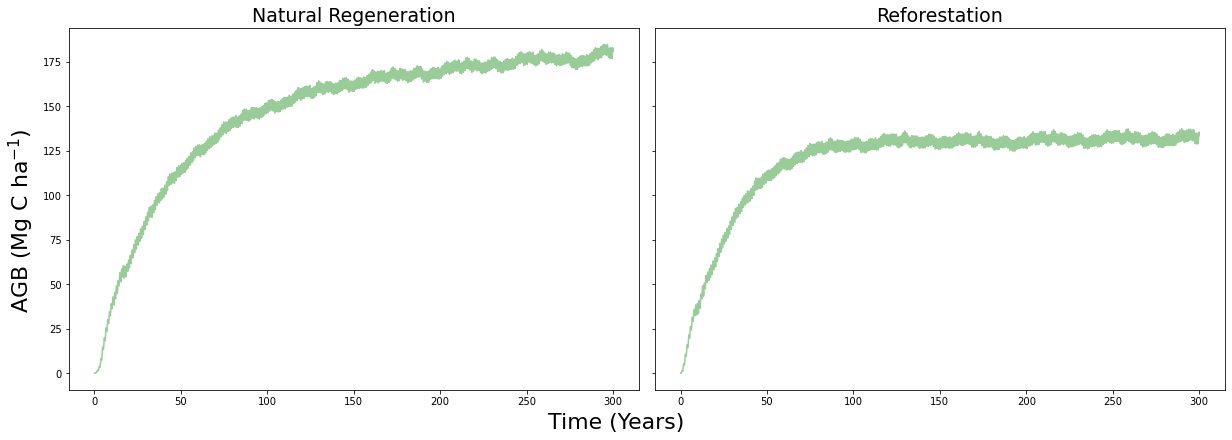

In [4]:
AGB_nat = fates_nat.FATES_VEGC_ABOVEGROUND_SZPF  * 10000 * 0.001 * 2
AGB_nat = AGB_nat.sum(dim='fates_levscpf')

AGB_ref = fates_ref.FATES_VEGC_ABOVEGROUND_SZPF  * 10000 * 0.001 * 2
AGB_ref = AGB_ref.sum(dim='fates_levscpf')

fig1, ((f1ax0,f1ax1)) = plt.subplots(nrows=1,ncols=2, figsize=(17,6), constrained_layout=True, sharey=True, sharex=True)

f1ax0.plot(time_nat, AGB_nat, color='green', label = 'FATES', alpha = 0.4)    
f1ax0.set_title(r'Natural Regeneration', fontsize = 19)

f1ax1.plot(time_ref, AGB_ref, color='green', label = 'FATES', alpha = 0.4)    
f1ax1.set_title(r'Reforestation', fontsize = 19)

fig1.supxlabel(r'Time (Years)', fontsize=22)
fig1.supylabel(r'AGB (Mg C ha$^{-1}$)', fontsize=22)

Text(0.02, 0.5, 'AGB (Mg C ha$^{-1}$)')

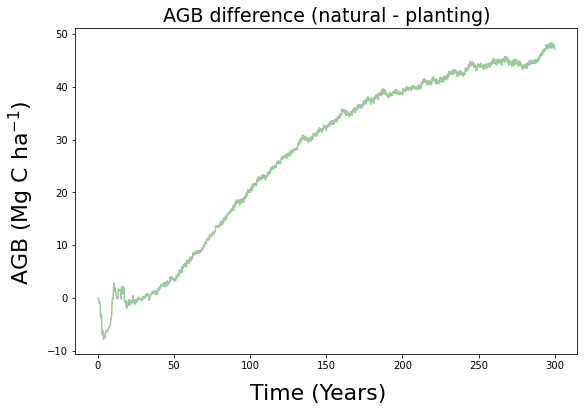

In [5]:
fig1, ((f1ax0)) = plt.subplots(nrows=1,ncols=1, figsize=(9,6))

f1ax0.plot(time_nat, AGB_nat - AGB_ref, color='green', label = 'FATES', alpha = 0.4)    
f1ax0.set_title(r'AGB difference (natural - planting)', fontsize = 19)

fig1.supxlabel(r'Time (Years)', fontsize=22)
fig1.supylabel(r'AGB (Mg C ha$^{-1}$)', fontsize=22)

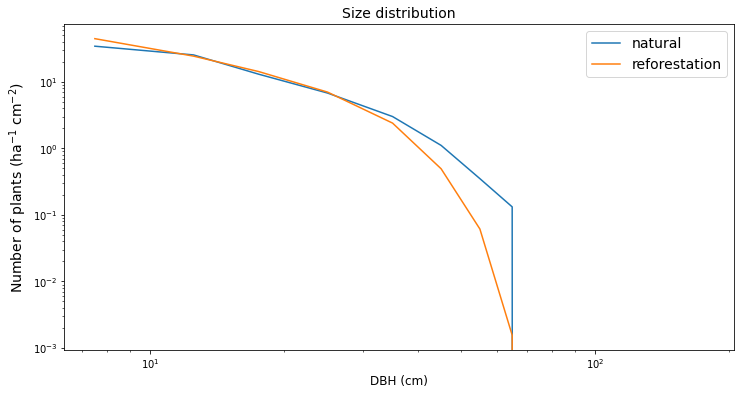

In [6]:
# size bins are LOWER bounds. Remove the fist bin - but add an extra bin to catch trees over last bin edge
cohort_size_bins_ex = np.append(cohort_size_bins[1:], 250)
fates_sizebin_mids = (cohort_size_bins_ex[0:-1] + cohort_size_bins_ex[1:])/2
fates_sizebin_widths = cohort_size_bins_ex[1:] - cohort_size_bins_ex[:-1]

NPLANT_SZ_nat = fates_nat.FATES_NPLANT_SZ * 10000
NPLANT_SZ_ref = fates_ref.FATES_NPLANT_SZ * 10000

nplant_nat = NPLANT_SZ_nat.isel(time=slice(tave_start,tave_stop)).mean(dim='time') 
nplant_nat = np.squeeze(nplant_nat)
nplant_nat = np.squeeze(nplant_nat[1:,])/fates_sizebin_widths

nplant_ref = NPLANT_SZ_ref.isel(time=slice(tave_start,tave_stop)).mean(dim='time') 
nplant_ref = np.squeeze(nplant_ref)
nplant_ref = np.squeeze(nplant_ref[1:,])/fates_sizebin_widths

fig2, ((f2ax0)) = plt.subplots(nrows=1,ncols=1, figsize=(12,6))

f2ax0.plot(fates_sizebin_mids, nplant_nat,  label = 'natural')
f2ax0.plot(fates_sizebin_mids, nplant_ref,  label = 'reforestation')
    
f2ax0.set_title(r'Size distribution', fontsize = 14)
f2ax0.set_ylabel(r'Number of plants (ha$^{-1}$ cm$^{-2}$)', fontsize = 14)
f2ax0.set_xlabel(r'DBH (cm)', fontsize = 12)    

f2ax0.legend(fontsize=14)
f2ax0.set_yscale('log')
f2ax0.set_xscale('log')

(3600, 13)
(3600, 1, 13)


Text(0, 0.5, 'Cohort Size (cm)')

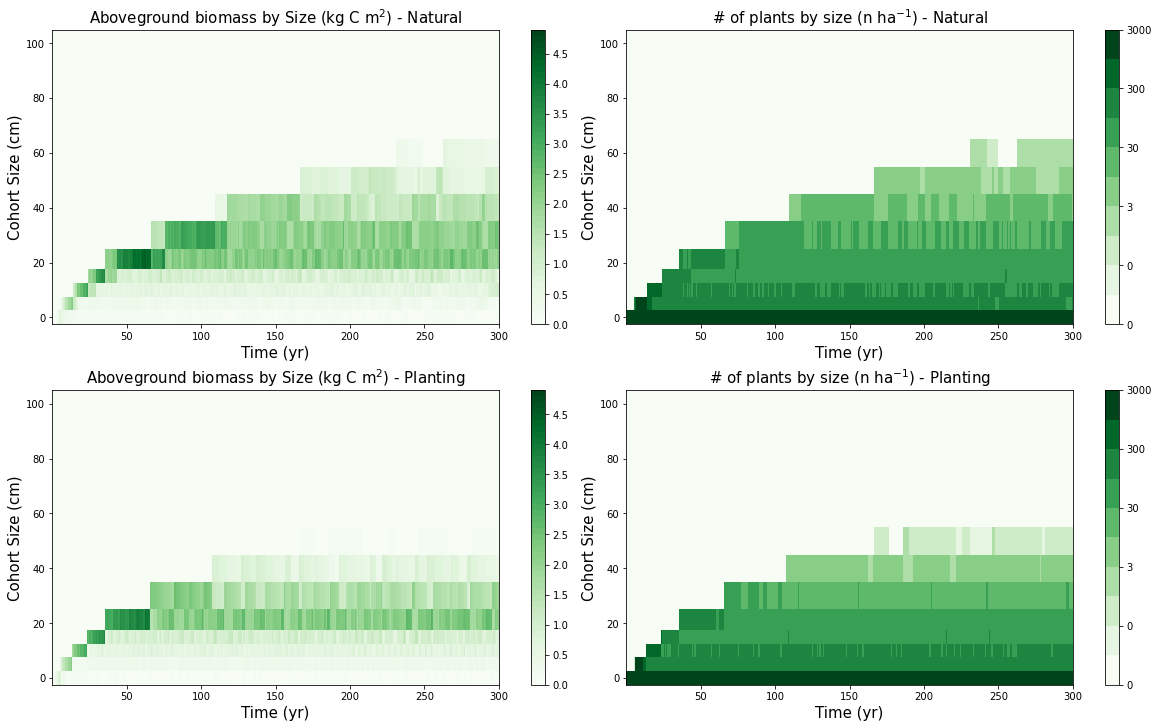

In [7]:
# population numbers as a function of cohort size
NPLANT_SZ_nat = np.squeeze(fates_nat.FATES_NPLANT_SZ) * 10000
NPLANT_SZ_ref = np.squeeze(fates_ref.FATES_NPLANT_SZ) * 10000

print(NPLANT_SZ_ref.shape)


VEGC_ABOVEGROUND_SZPF_nat = fa.scpf_to_scls_by_pft(fates_nat.FATES_VEGC_ABOVEGROUND_SZPF, fates_nat)
VEGC_ABOVEGROUND_SZ_nat  = VEGC_ABOVEGROUND_SZPF_nat.sum(dim='fates_levpft')

VEGC_ABOVEGROUND_SZPF_ref = fa.scpf_to_scls_by_pft(fates_ref.FATES_VEGC_ABOVEGROUND_SZPF, fates_ref)
VEGC_ABOVEGROUND_SZ_ref  = VEGC_ABOVEGROUND_SZPF_ref.sum(dim='fates_levpft')

print(VEGC_ABOVEGROUND_SZ_ref.shape)


fig2, ((f2ax0, f2ax1),(f2ax2,f2ax3)) = plt.subplots(nrows=2,ncols=2, figsize=(16,10),constrained_layout=True)

## set up the first plot: evolution of AGB of plants of a given size
levels = np.arange(0.,5, 0.1)
cmap = plt.get_cmap('Greens')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f2ax0.pcolormesh(time_nat, cohort_size_bins, VEGC_ABOVEGROUND_SZ_nat[:,0,:].transpose(), cmap=cmap, norm=norm)
fig2.colorbar(im, ax=f2ax0)
f2ax0.set_title(r'Aboveground biomass by Size (kg C m$^2$) - Natural', fontsize=15)
f2ax0.set_xlabel('Time (yr)', fontsize=15)
f2ax0.set_ylabel('Cohort Size (cm)', fontsize=15)

levels = np.array([0, 0.1,0.3,1.,3.,10.,30., 100., 300., 1000., 3000]) # do a pseudo-log scale here
cmap = plt.get_cmap('Greens')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f2ax1.pcolormesh(time_nat, cohort_size_bins, (NPLANT_SZ_nat).transpose(),
                      cmap=cmap, norm=norm)
fig2.colorbar(im, ax=f2ax1)
f2ax1.set_title(r'# of plants by size (n ha$^{-1}$) - Natural', fontsize=15)
f2ax1.set_xlabel('Time (yr)', fontsize=15)
f2ax1.set_ylabel('Cohort Size (cm)', fontsize=15)

## set up the first plot: evolution of AGB of plants of a given size
levels = np.arange(0.,5, 0.1)
cmap = plt.get_cmap('Greens')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f2ax2.pcolormesh(time_ref, cohort_size_bins, VEGC_ABOVEGROUND_SZ_ref[:,0,:].transpose(), cmap=cmap, norm=norm)
fig2.colorbar(im, ax=f2ax2)
f2ax2.set_title(r'Aboveground biomass by Size (kg C m$^2$) - Planting', fontsize=15)
f2ax2.set_xlabel('Time (yr)', fontsize=15)
f2ax2.set_ylabel('Cohort Size (cm)', fontsize=15)

levels = np.array([0, 0.1,0.3,1.,3.,10.,30., 100., 300., 1000., 3000]) # do a pseudo-log scale here
cmap = plt.get_cmap('Greens')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f2ax3.pcolormesh(time_ref, cohort_size_bins, (NPLANT_SZ_ref).transpose(),
                      cmap=cmap, norm=norm)
fig2.colorbar(im, ax=f2ax3)
f2ax3.set_title(r'# of plants by size (n ha$^{-1}$) - Planting', fontsize=15)
f2ax3.set_xlabel('Time (yr)', fontsize=15)
f2ax3.set_ylabel('Cohort Size (cm)', fontsize=15)

Text(0.02, 0.5, 'Soil Carbon (g C m$^{-2}$)')

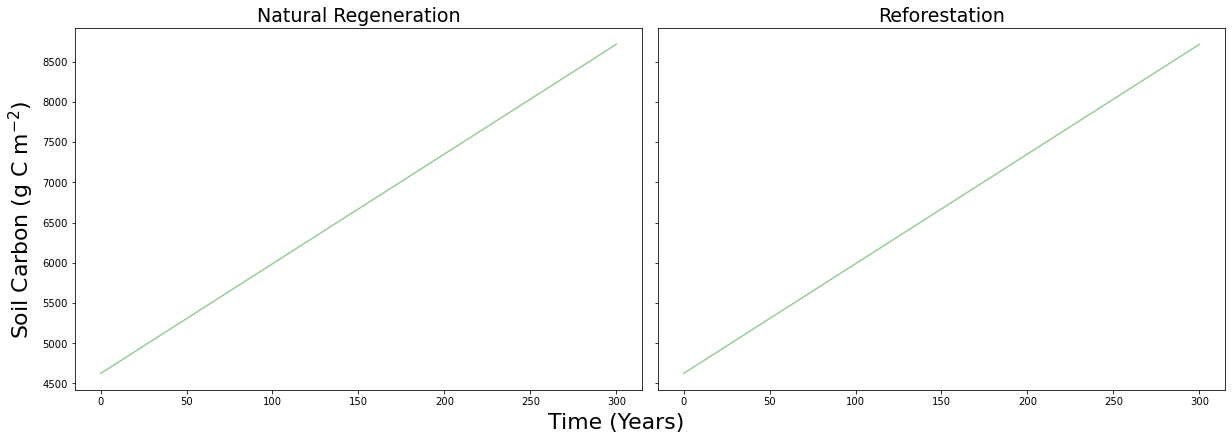

In [9]:
soil_nat = fates_nat.SOILC  
soil_ref = fates_ref.SOILC

fig1, ((f1ax0,f1ax1)) = plt.subplots(nrows=1,ncols=2, figsize=(17,6), constrained_layout=True, sharey=True, sharex=True)

f1ax0.plot(time_nat, soil_nat, color='green', label = 'FATES', alpha = 0.4)    
f1ax0.set_title(r'Natural Regeneration', fontsize = 19)

f1ax1.plot(time_ref, soil_ref, color='green', label = 'FATES', alpha = 0.4)    
f1ax1.set_title(r'Reforestation', fontsize = 19)

fig1.supxlabel(r'Time (Years)', fontsize=22)
fig1.supylabel(r'Soil Carbon (g C m$^{-2}$)', fontsize=22)
